Created 7/10/2026

Purpose: To analyze the result of batch processing LCs with claude_files/batch_test_guesses.py. 

In [58]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import fitsio
from astropy.io import fits

from split_smarts_lc import *

import sys
sys.path.insert(0, "claude_files")

In [16]:
# Helper Functions (put finished helper functions here)
def to_even_cadence(time, flux, flux_err=None, timestep=1800):
    """
    Maps a light curve onto an evenly-spaced time grid at the given cadence.
    Each original point is placed at its nearest grid index (no averaging);
    timesteps with no matching data point are filled with NaN.

    Args:
        time (array): time stamps, in days.
        flux (array): flux values.
        flux_err (array): flux_err values, if available.
        timestep (float): cadence of the output grid, in seconds (default 1800 s).

    Returns:
        time_even (array): evenly-spaced time stamps, in days.
        flux_even (array): flux values on the even grid, with NaN for gaps.
        flux_err (array): flux_err values on the even grid, if provided.
    """
    time = np.asarray(time, dtype=float)
    flux = np.asarray(flux, dtype=float)
    dt = timestep / 86400.0  # seconds -> days    
    
    # sanity check: does the requested timestep match the data's actual cadence?
    diffs = np.round(np.diff(time) * 86400).astype(int)
    values, counts = np.unique(diffs, return_counts=True)
    mode_timestep = values[np.argmax(counts)]
    if not np.isclose(timestep, mode_timestep, rtol=0.01):
        warnings.warn(
            f"Requested timestep ({timestep} s) does not match the mode "
            f"cadence of the input time array ({mode_timestep} s). "
            "The wrong timestep may have been provided."
        )

    n_bins = int(round((time[-1] - time[0]) / dt)) + 1
    time_even = time[0] + np.arange(n_bins) * dt

    idx = np.round((time - time[0]) / dt).astype(int)
    valid = (idx >= 0) & (idx < n_bins)

    flux_even = np.full(n_bins, np.nan)
    flux_even[idx[valid]] = flux[valid]
    
    if flux_err is not None:
        flux_err_even = np.full(n_bins, np.nan)
        flux_err_even[idx[valid]] = flux_err[valid]
        return time_even, flux_even, flux_err_even
        
    return time_even, flux_even

def bin_lc(time, flux, flux_err=None, binsize=1800):
    """
    Bins a timeseries to the desired cadence. Works much faster than Lightkurve's built in binning function.

    Args:
        time (:obj:`array`): time stamps of the lightcurve.
        flux (:obj:`array`): flux values of the lightcurve.
        flux_err (:obj:`array`): flux error values of the lightcurve.
        binsize (:obj:`float`): the size of the bins, in units of seconds.

    Returns:
    Two parameters, or three if a flux_err is also provided.

        - time_bin (:obj:`array`): binned time stamps of the lightcurve.
        - flux_bin (:obj:`array`): binned flux values of the lightcurve.
        - flux_err_bin (:obj:`array`): binned flux errors values of the lightcurve. Only returned if an array is passed to flux_err.
    """
    time_bin = np.arange(time[0], time[-1], binsize / 86400.0) # seconds -> days 
    flux_bin = stats.binned_statistic(time, flux, bins=time_bin)[0]

    # If flux_err is populated, assume the errors combine as the root-mean-square
    if flux_err is not None:
        # define a function to calculate the root mean square error of each bin
        rmse_func = (lambda x: np.sqrt(np.nansum(np.square(x))) / len(np.atleast_1d(x))
                    if np.any(np.isfinite(x))
                    else np.nan)
        flux_err_bin = stats.binned_statistic(time, flux_err, statistic=rmse_func, bins=time_bin)[0]
        return time_bin[:-1], flux_bin, flux_err_bin

    return time_bin[:-1], flux_bin


def unpack_smarts(fname, sectors=None):
    """
    Unpacks a SMARTS light curve FITS file and returns the time, flux, and expected period. Applies normalization and maps it to even cadence for conveniences

    Args:
        filename (str): Path to the SMARTS light curve FITS file.
    Returns:
        time (array): time stamps, in days. 
        flux (array): flux values, normalized to 1 and centered around 0.
        time_even (array): time stamps, mapped to even cadence.
        flux_even (array): flux, mapped to even cadence.        
        header (float): the header of the FITS file, which contains metadata including the expected rotation period.
    """
    hdul = fits.open(fname)
    lc = hdul["LIGHTCURVE"].data
    time = lc["time"]
    flux = lc["flux"] - 1
    
    # split the light curve and then recombine it to remove gaps and flagged segments, 
    segments, diagnostics = split_lightcurve(time, flux, n_segments=27)
    time_stitch, flux_stitch, sectors = recombine_segments(
        segments, diagnostics, 
        drop_gap_points=True, drop_flagged_segments=True,
        sectors=sectors)
    
    # then map to even cadence
    time_even, flux_even = to_even_cadence(time_stitch, flux_stitch, timestep=1800)
    header = hdul[0].header
    return time, flux, segments, diagnostics, time_stitch, flux_stitch, time_even, flux_even, header, sectors



In [20]:
fname = 'data/tess/smarts-tess-v1.0-299999.fits'
time, flux, segments, diagnostics, time_stitch, flux_stitch, time_even, flux_even, header, sectors = unpack_smarts(fname)
header['PERIOD']

54.0625

In [ ]:
# set up mini database of SMARTS light curves to explore
# get a sense of the period distribution of the SMARTS light curves
file_nums = np.arange(0, 100000, 100)
fns = [f"data/tess/smarts-tess-v1.0-{num:06d}.fits" for num in file_nums]
periods = [fitsio.read_header(fn)['PERIOD'] for fn in fns]
incls = [fitsio.read_header(fn)['INCL'] for fn in fns]
diffrot = [fitsio.read_header(fn)['DIFFROT'] for fn in fns]
tspot = [fitsio.read_header(fn)['TSPOT'] for fn in fns]
activity = [fitsio.read_header(fn)['ACTIVITY'] for fn in fns]
bfly = [fitsio.read_header(fn)['BFLY'] for fn in fns]

# make into dataframe
fdf = pd.DataFrame(data={'filename': fns, 'periods': periods,'incls': incls,  'diffrot': diffrot, 'tspot': tspot, 'activity': activity, 'bfly': bfly})

# downselect to stuff that is likely to be more detectable
fdf1 = fdf[fdf.tspot > 3]

In [29]:
# read in the summary plot
df = pd.read_csv('results_products/summary.csv')
df[:4]

,star_id,method,n_candidates,found_true_period,rank_of_true_period,matched_P0,true_period,PERIOD,ACTIVITY,CYCLE,OVERLAP,INCL,MINLAT,MAXLAT,DIFFROT,TSPOT,BFLY
0,smarts-tess-v1.0-000000,acf_fft,10,True,10.0,0.10332,0.1005,0.1005,7.7503,5.233,0.1513,0.5069,17.969299,33.285099,0.2259,2.9197,True
1,smarts-tess-v1.0-000000,lombscargle,10,False,NaN,NaN,0.1005,0.1005,7.7503,5.233,0.1513,0.5069,17.969299,33.285099,0.2259,2.9197,True
2,smarts-tess-v1.0-000000,pairwise_histogram,10,False,NaN,NaN,0.1005,0.1005,7.7503,5.233,0.1513,0.5069,17.969299,33.285099,0.2259,2.9197,True
3,smarts-tess-v1.0-000000,wavelet,10,False,NaN,NaN,0.1005,0.1005,7.7503,5.233,0.1513,0.5069,17.969299,33.285099,0.2259,2.9197,True


In [43]:
gdf = df.groupby('star_id').agg({'n_candidates':sum, "found_true_period":np.any, 'PERIOD':'first', 'ACTIVITY':'first', 'INCL':'first'})

/var/folders/wt/910qvr9933l5g771nq9f0jj4wkv2lb/T/ipykernel_72355/4285796184.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  gdf = df.groupby('star_id').agg({'n_candidates':sum, "found_true_period":np.any, 'PERIOD':'first', 'ACTIVITY':'first', 'INCL':'first'})
/var/folders/wt/910qvr9933l5g771nq9f0jj4wkv2lb/T/ipykernel_72355/4285796184.py:1: FutureWarning: The provided callable <function any at 0x119393d80> is currently using SeriesGroupBy.any. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "any" instead.
  gdf = df.groupby('star_id').agg({'n_candidates':sum, "found_true_period":np.any, 'PERIOD':'first', 'ACTIVITY':'first', 'INCL':'first'})


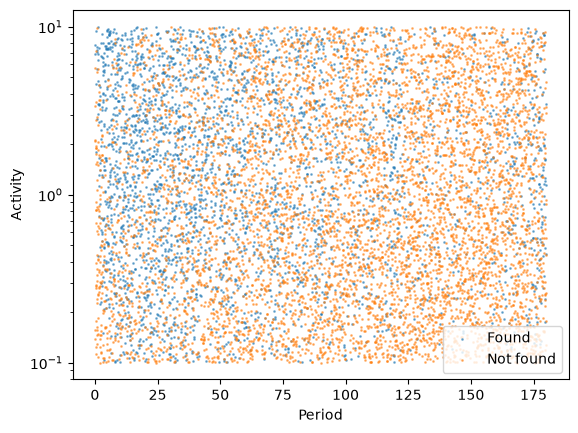

In [41]:
plt.scatter(gdf[gdf.found_true_period==True].PERIOD, gdf[gdf.found_true_period==True].ACTIVITY, s=1, alpha=.5, label='Found')
plt.scatter(gdf[gdf.found_true_period==False].PERIOD, gdf[gdf.found_true_period==False].ACTIVITY, s=1, alpha=.5, label='Not found')
plt.yscale('log')
plt.xlabel('Period')
plt.ylabel('Activity')
plt.legend()


In [44]:
df.columns

Index(['star_id', 'method', 'n_candidates', 'found_true_period',
       'rank_of_true_period', 'matched_P0', 'true_period', 'PERIOD',
       'ACTIVITY', 'CYCLE', 'OVERLAP', 'INCL', 'MINLAT', 'MAXLAT', 'DIFFROT',
       'TSPOT', 'BFLY'],
      dtype='object')

In [54]:
cut = (gdf.PERIOD < 10) & (gdf.found_true_period == False) & (gdf.ACTIVITY > 1)
gdf[cut].index[::10].values

with open("fast_period_failures.txt", "w") as f:
    f.write("\n".join(gdf[cut].index[::10].values))
    f.write("\n")

# Claude Plots

## High pass batch

In [75]:
DEFAULT_SMOOTH_WINDOWS = (2.0, 5.0, 10.0, 20.0, 40.0)
DEFAULT_MAX_PERIOD = 15.0  # matches guess_acf_fft_highpass's own default
PERIOD_BAND_EDGES = [0, 1, 5, 10, 15, 20, 30, 50, np.inf]
PERIOD_BAND_LABELS = ["<1d", "1-5d", "5-10d", "10-15d", "15-20d", "20-30d", "30-50d", ">50d"]

In [83]:
len(np.unique(summary_df[summary_df.true_period > 20].star_id.values))

1893

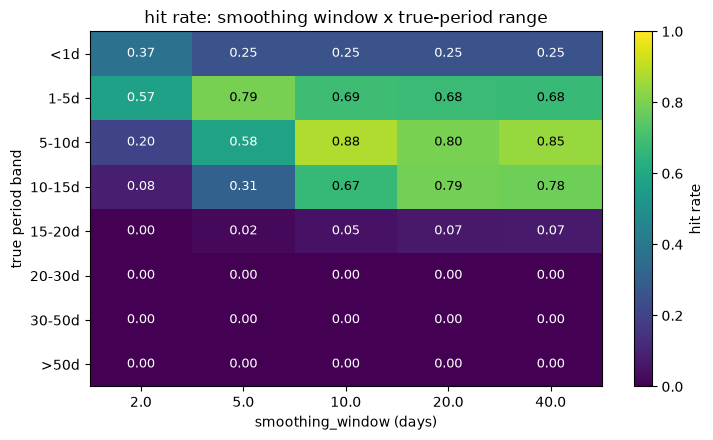

In [76]:
# from batch_test_act_fft_highpass import make_diagnostic_plots
summary_df = pd.read_csv('results_products/batch2_highpass/summary.csv')
windows = sorted(summary_df["smoothing_window"].unique())

valid = summary_df.dropna(subset=["true_period"]).copy()
if len(valid):
    valid["period_band"] = pd.cut(
        valid["true_period"], bins=PERIOD_BAND_EDGES, labels=PERIOD_BAND_LABELS
    )
    pivot = valid.pivot_table(
        index="period_band", columns="smoothing_window",
        values="found_true_period", aggfunc="mean", observed=True,
    ).reindex(index=PERIOD_BAND_LABELS, columns=windows)

    fig, ax = plt.subplots(figsize=(1.1 * len(windows) + 2, 4.5))
    im = ax.imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(windows)))
    ax.set_xticklabels(windows)
    ax.set_yticks(range(len(PERIOD_BAND_LABELS)))
    ax.set_yticklabels(PERIOD_BAND_LABELS)
    ax.set_xlabel("smoothing_window (days)")
    ax.set_ylabel("true period band")
    ax.set_title("hit rate: smoothing window x true-period range")
    for yi in range(pivot.shape[0]):
        for xi in range(pivot.shape[1]):
            v = pivot.values[yi, xi]
            if np.isfinite(v):
                ax.text(xi, yi, f"{v:.2f}", ha="center", va="center",
                            color="white" if v < 0.6 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, label="hit rate")
    fig.tight_layout()
    # fig.savefig(outdir / "hit_rate_window_x_period.png", dpi=150)
    plt.show();
    plt.close(fig)

## Full batch testing

In [ ]:
# plotting functions from claude
"""
analysis_plots.py

Reusable plotting functions for the guess_* detectability analysis of
batch_test_guesses.py output (summary.csv). Each function takes a
dataframe and returns a (fig, ax) pair so you can display, save, or
further tweak them yourself.

Usage
-----
    import pandas as pd
    from analysis_plots import *

    df = pd.read_csv("summary.csv")
    df["found_true_period"] = df["found_true_period"].astype(bool)

    restricted, merged = build_restricted_subsample(df, period_cutoff=50)

    plot_hitrate_vs_period_structural(df)
    plot_zero_candidates_vs_activity(df, restricted.index)
    plot_absdiffrot_detectability(restricted)
    plot_param_sweeps(restricted)
    imp = fit_detectability_model(restricted)
    plot_feature_importance(imp)
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# each method's default max-period search ceiling, derived from
# guess_acf_fft / guess_pairwise_histogram / guess_lombscargle /
# guess_wavelet defaults and the ~357-day SMARTS baseline
METHOD_CUTOFFS = {
    "acf_fft": 59.5,
    "pairwise_histogram": 119.0,
    "lombscargle": 178.5,
    "wavelet": 178.5,
}
METHOD_COLORS = {
    "acf_fft": "C0", "lombscargle": "C1",
    "pairwise_histogram": "C2", "wavelet": "C3",
}


def plot_hitrate_vs_period_structural(df: pd.DataFrame, bin_width: float = 5.0):
    """Plot 1: hit rate vs. true period per method, with each method's
    structural search-range ceiling overlaid as a dashed vertical line.

    Reveals whether a method's failures at long periods are a hard
    search-range wall (hit rate -> exactly 0 right at the ceiling) rather
    than a gradual physical difficulty.

    Parameters
    ----------
    df : full per-(star, method) summary dataframe, with boolean
        'found_true_period', numeric 'true_period', and 'method' columns.
    bin_width : width in days of the period bins used for the hit-rate curve.

    Returns
    -------
    fig, ax
    """
    df = df.copy()
    bins = np.arange(0, df["true_period"].max() + bin_width, bin_width)
    df["period_bin"] = pd.cut(df["true_period"], bins)
    tab = df.pivot_table(
        index="period_bin", columns="method", values="found_true_period",
        aggfunc="mean", observed=True,
    )
    centers = [iv.mid for iv in tab.index]

    fig, ax = plt.subplots(figsize=(9, 5.5))
    for m in tab.columns:
        ax.plot(centers, tab[m], marker="o", ms=3, label=m,
                color=METHOD_COLORS.get(m))
    for m, cutoff in METHOD_CUTOFFS.items():
        if m in tab.columns:
            ax.axvline(cutoff, color=METHOD_COLORS[m], ls="--", lw=1, alpha=0.6)
    ax.set_xlabel("true period (days)")
    ax.set_ylabel("hit rate (true period in top-10 candidates)")
    ax.set_title("Hit rate vs true period, by method\n"
                  "(dashed lines = predicted search-range ceiling per method)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    return fig, ax


def build_restricted_subsample(df: pd.DataFrame, period_cutoff: float = 50.0):
    """Build the period-controlled subsample used to isolate genuine
    physical difficulty from the search-range ceiling effect in Plot 1.

    Restricting to true_period <= period_cutoff (well below every
    method's ceiling) means all methods have equal structural opportunity
    to find the period, so any remaining hit-rate variation must come
    from the light curve's physical parameters rather than search range.

    Parameters
    ----------
    df : full per-(star, method) summary dataframe.
    period_cutoff : days; should be safely below the smallest method
        ceiling (default 50, vs. acf_fft's ~59.5d ceiling).

    Returns
    -------
    restricted : pd.DataFrame, one row per star (index=star_id) with
        spot-model parameters, 'n_methods_found', 'found_by_any', for
        stars with true_period <= period_cutoff.
    merged : same, but for every star (no period restriction) -- handy
        for comparison.
    """
    param_cols = ["PERIOD", "ACTIVITY", "CYCLE", "OVERLAP", "INCL",
                  "MINLAT", "MAXLAT", "DIFFROT", "TSPOT", "BFLY"]

    piv = df.pivot_table(
        index="star_id", columns="method", values="found_true_period",
        aggfunc="first",
    ).astype(bool)
    n_found = piv.sum(axis=1)
    found_by_any = piv.any(axis=1)

    params = df.drop_duplicates("star_id").set_index("star_id")[param_cols]
    merged = params.join(n_found.rename("n_methods_found")).join(
        found_by_any.rename("found_by_any")
    )
    restricted = merged[merged["PERIOD"] <= period_cutoff].copy()
    return restricted, merged


def plot_zero_candidates_vs_activity(df: pd.DataFrame, star_ids, n_bins: int = 8):
    """Plot 4: rate of complete candidate-generation failure (n_candidates
    == 0, i.e. the method raised/found nothing at all) vs. spot ACTIVITY,
    for the methods that can fail this way (pairwise_histogram, wavelet).

    Parameters
    ----------
    df : full per-(star, method) summary dataframe, must include
        'n_candidates' and 'ACTIVITY'.
    star_ids : iterable of star_id values to restrict to (typically the
        period-controlled subsample from build_restricted_subsample, so
        this isn't confounded by the search-range ceiling).
    n_bins : number of log-spaced ACTIVITY bins.

    Returns
    -------
    fig, ax
    """
    sub = df[df["star_id"].isin(star_ids)]
    fig, ax = plt.subplots(figsize=(7, 5))
    edges = np.geomspace(max(sub["ACTIVITY"].min(), 0.01), sub["ACTIVITY"].max(), n_bins + 1)
    for m in ["pairwise_histogram", "wavelet"]:
        s = sub[sub["method"] == m].copy()
        if not len(s):
            continue
        s["zero"] = s["n_candidates"] == 0
        b = pd.cut(s["ACTIVITY"], edges)
        rate = s.groupby(b, observed=True)["zero"].mean()
        centers = [iv.mid for iv in rate.index]
        ax.plot(centers, rate.values, marker="o", color=METHOD_COLORS.get(m), label=m)
    ax.set_xscale("log")
    ax.set_xlabel("ACTIVITY (solar-normalized spot activity level)")
    ax.set_ylabel("rate of ZERO candidates generated\n(complete detection failure)")
    ax.set_title("Complete candidate-generation failure vs spot activity level")
    ax.legend()
    fig.tight_layout()
    return fig, ax


def plot_absdiffrot_detectability(restricted: pd.DataFrame, n_bins: int = 7):
    """Plot 3: detection rate vs. |DIFFROT| (magnitude of differential-
    rotation shear), on the period-controlled subsample.

    Using the absolute value rather than signed DIFFROT is deliberate:
    it's shear magnitude, not direction, that smears a single coherent
    rotation period into a spread across latitudes.

    Parameters
    ----------
    restricted : output of build_restricted_subsample(), must include
        'DIFFROT' and 'found_by_any'.
    n_bins : number of linear |DIFFROT| bins.

    Returns
    -------
    fig, ax
    """
    restricted = restricted.copy()
    restricted["abs_DIFFROT"] = restricted["DIFFROT"].abs()

    fig, ax = plt.subplots(figsize=(6, 4.5))
    edges = np.linspace(0, restricted["abs_DIFFROT"].max(), n_bins + 1)
    b = pd.cut(restricted["abs_DIFFROT"], edges)
    rate = restricted.groupby(b, observed=True)["found_by_any"].mean()
    n = restricted.groupby(b, observed=True)["found_by_any"].count()
    centers = [iv.mid for iv in rate.index]
    ax.plot(centers, rate.values, marker="o", color="firebrick")
    for x, y, ni in zip(centers, rate.values, n.values):
        ax.annotate(f"n={ni}", (x, y), textcoords="offset points",
                     xytext=(0, 8), fontsize=8, ha="center")
    ax.set_xlabel("|DIFFROT|  (magnitude of differential-rotation shear)")
    ax.set_ylabel("detection rate")
    ax.set_ylim(0, 1)
    ax.set_title("Detectability vs magnitude of differential rotation")
    fig.tight_layout()
    return fig, ax


def plot_param_sweeps(restricted: pd.DataFrame, n_bins: int = 8):
    """Plot 2: detection rate vs. each of 6 spot-model parameters, as a
    2x3 grid of binned sweeps, on the period-controlled subsample.

    Parameters
    ----------
    restricted : output of build_restricted_subsample().
    n_bins : number of linear bins per parameter.

    Returns
    -------
    fig, axes
    """
    params = ["ACTIVITY", "DIFFROT", "PERIOD", "MINLAT", "TSPOT", "INCL"]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, param in zip(axes.flat, params):
        edges = np.linspace(restricted[param].min(), restricted[param].max(), n_bins + 1)
        b = pd.cut(restricted[param], edges)
        rate = restricted.groupby(b, observed=True)["found_by_any"].mean()
        centers = [iv.mid for iv in rate.index]
        ax.plot(centers, rate.values, marker="o", color="steelblue")
        ax.set_xlabel(param)
        ax.set_ylabel("detection rate")
        ax.set_ylim(0, 1)
        ax.set_title(param)
    fig.suptitle(
        "Detectability (found by >=1 method) vs spot-model parameters\n"
        "(period-controlled subsample: all methods have equal search range)",
        fontsize=12,
    )
    fig.tight_layout()
    return fig, axes


def fit_detectability_model(restricted: pd.DataFrame) -> pd.Series:
    """Fit a random forest predicting 'found_by_any' from the spot-model
    parameters (using |DIFFROT| rather than signed DIFFROT) and return
    feature importances, sorted descending.

    Requires scikit-learn.

    Parameters
    ----------
    restricted : output of build_restricted_subsample().

    Returns
    -------
    pd.Series of feature importances, indexed by parameter name, sorted
    descending. Also prints 5-fold cross-validated ROC-AUC.
    """
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import cross_val_score

    restricted = restricted.copy()
    restricted["abs_DIFFROT"] = restricted["DIFFROT"].abs()
    feat_cols = ["PERIOD", "ACTIVITY", "CYCLE", "OVERLAP", "INCL",
                 "MINLAT", "MAXLAT", "abs_DIFFROT", "TSPOT", "BFLY"]
    X = restricted[feat_cols].copy()
    X["BFLY"] = X["BFLY"].astype(int)
    y = restricted["found_by_any"].astype(int)

    rf = RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=20,
        random_state=0, n_jobs=-1,
    )
    scores = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
    print(f"5-fold CV ROC-AUC: {scores.mean():.3f} +/- {scores.std():.3f}")

    rf.fit(X, y)
    return pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)


def plot_feature_importance(importances: pd.Series):
    """Plot 5: horizontal bar chart of random-forest feature importances
    from fit_detectability_model().

    Parameters
    ----------
    importances : pd.Series as returned by fit_detectability_model().

    Returns
    -------
    fig, ax
    """
    fig, ax = plt.subplots(figsize=(7, 4.5))
    imp_sorted = importances.sort_values()
    ax.barh(imp_sorted.index, imp_sorted.values, color="slateblue")
    ax.set_xlabel("random forest feature importance")
    ax.set_title("What predicts detectability, among structurally-reachable LCs?\n"
                  "(predicting found-by-any-method)")
    fig.tight_layout()
    return fig, ax


5-fold CV ROC-AUC: 0.670 +/- 0.043


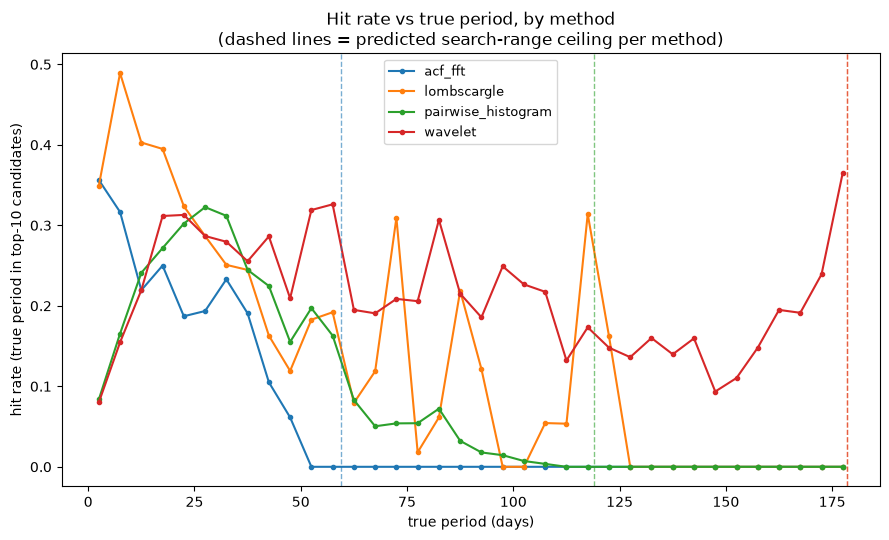

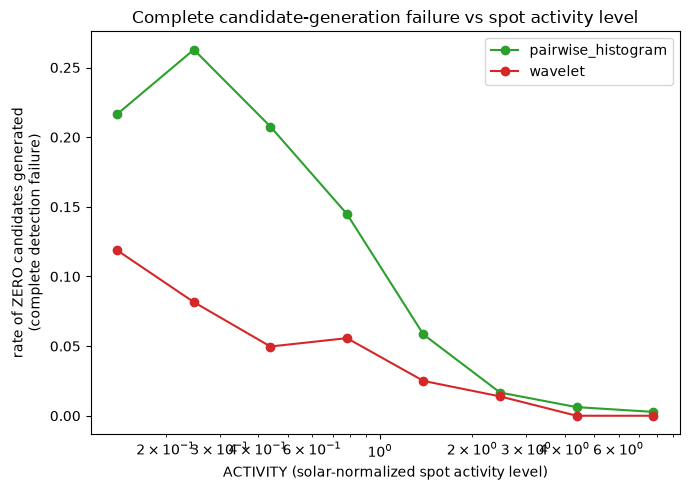

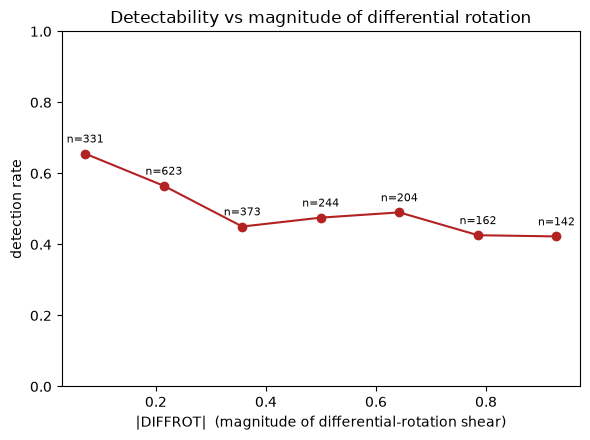

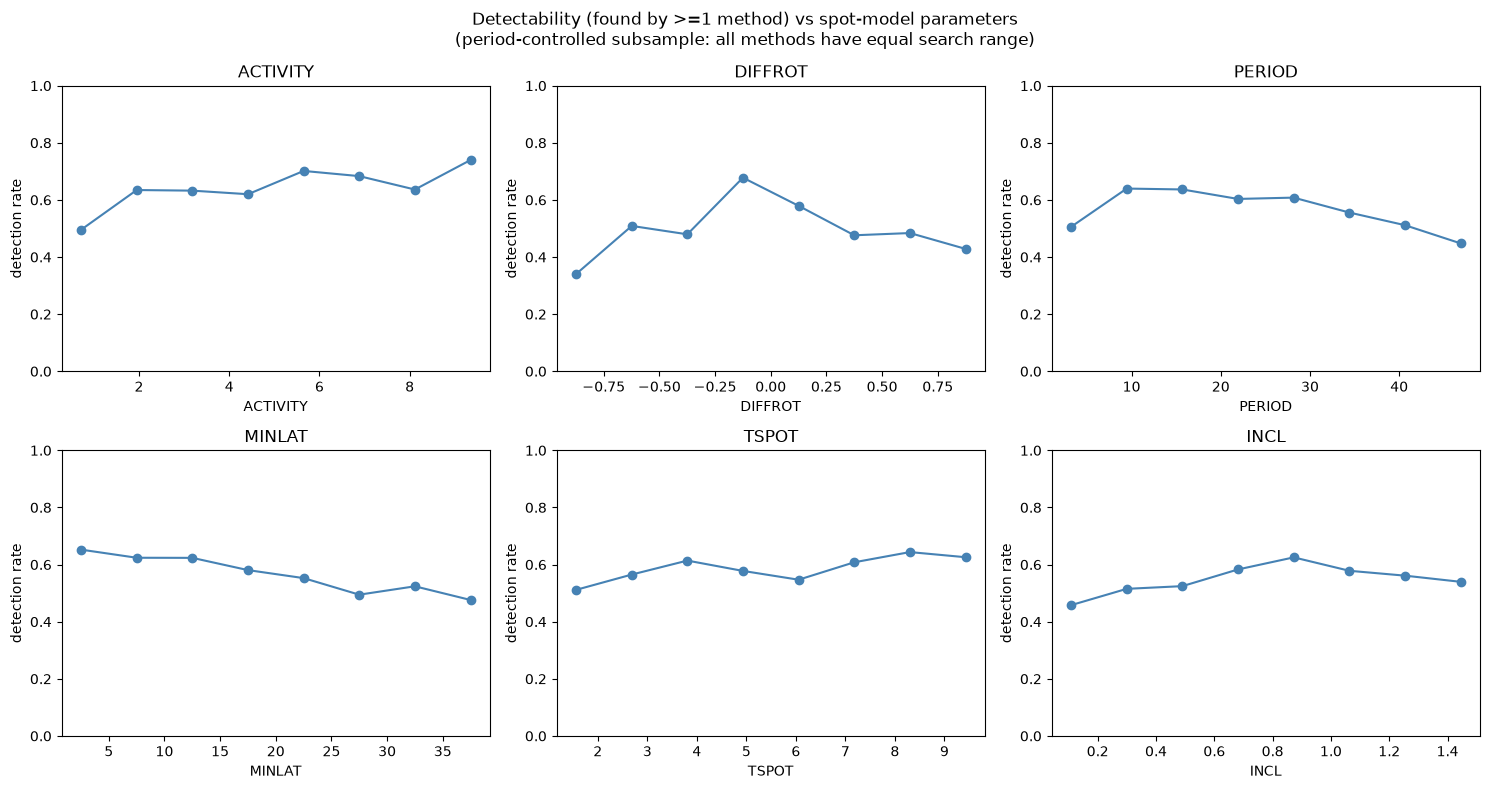

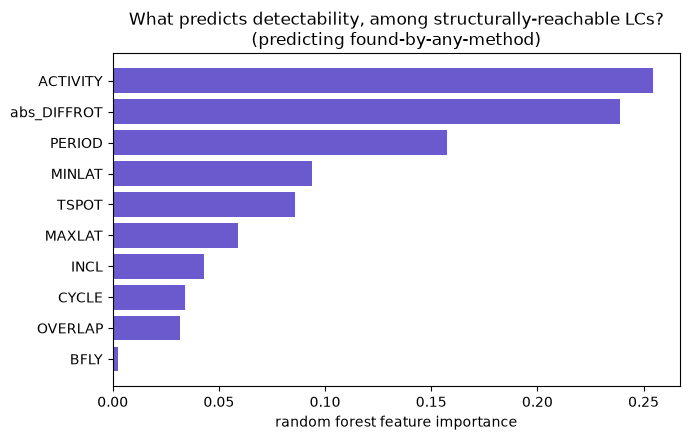

In [ ]:
# plots
df = pd.read_csv("results_products/summary.csv")
df["found_true_period"] = df["found_true_period"].astype(bool)

restricted, merged = build_restricted_subsample(df, period_cutoff=50)

plot_hitrate_vs_period_structural(df)
plot_zero_candidates_vs_activity(df, restricted.index)
plot_absdiffrot_detectability(restricted)
plot_param_sweeps(restricted)
imp = fit_detectability_model(restricted)
plot_feature_importance(imp)

plt.show()